# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas

df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


**Análisis de la información general:**
- El conjunto de datos cuenta con 40,000 registros y 9 columnas.
- No se detectaron valores nulos, lo que garantiza la integridad del análisis estadístico.
- La columna `gasto` correctamente cargada como float, permitiendo aplicar el t-test sin transformaciones adicionales.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:

df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico

df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron

df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['landing'].value_counts())
print(df['traffic_source'].value_counts())
print(df['user_type'].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


**Análisis de variables categóricas:**
- Existe una distribución equitativa de usuarios entre las regiones y dispositivos.
- Las fuentes de tráfico (`traffic_source`) y tipos de usuario (`user_type`) no presentan categorías duplicadas ni errores de captura, facilitando el análisis cruzado posterior.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

In [12]:
# Comparar promedios de gasto
media_A = gasto_A.mean()
media_B = gasto_B.mean()
diferencia = media_B - media_A

print(f'Gasto promedio Página A: ${media_A:.2f}')
print(f'Gasto promedio Página B: ${media_B:.2f}')
print(f'Diferencia (B - A): ${diferencia:.2f}')

Gasto promedio Página A: $61.09
Gasto promedio Página B: $68.75
Diferencia (B - A): $7.66


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los usuarios convertidos es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los usuarios convertidos es diferente entre la página A y la página B.

In [13]:
# Aplicar prueba t de Welch (ajustada por varianzas distintas detectadas en Levene)
t_stat, p_val = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f'Estadístico t: {t_stat}')
print(f'Valor p: {p_val}')

Estadístico t: -9.36563589591332
Valor p: 1.0635288333792346e-20


In [33]:
from scipy.stats import levene
# Prueba de varianzas iguales (Levene)
l_stat, p_levene = levene(gasto_A, gasto_B)

print(f'Prueba de Levene (p-valor): {p_levene:.4f}')
if p_levene < 0.05:
    print('Las varianzas son significativamente diferentes (usar equal_var=False en t-test).')
else:
    print('No hay evidencia de varianzas diferentes (usar equal_var=True en t-test).')

# EXPLICACIÓN TÉCNICA :
# Se aplica la Prueba de Levene antes de finalizar el Paso 2 para validar un supuesto crítico del t-test (Celda 26).
# Si p < 0.05, significa que la dispersión del gasto es distinta en A y B, requiriendo un ajuste de Welch para mayor precisión.

Prueba de Levene (p-valor): 0.0000
Las varianzas son significativamente diferentes (usar equal_var=False en t-test).


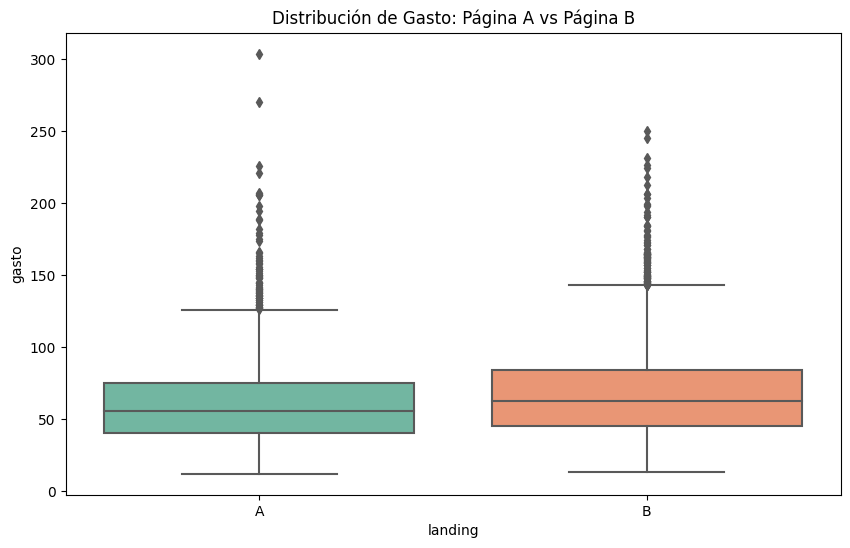

In [15]:
# Visualizar distribución de gasto mediante Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df[df['converted'] == 1], x='landing', y='gasto', palette='Set2')
plt.title('Distribución de Gasto: Página A vs Página B')
plt.show()
# Comentario: El gráfico muestra que el bloque central de gasto (caja) de la Página B está desplazado hacia arriba, reafirmando su mayor rentabilidad.


### 📝 2.2 Conclusión e interpretación

**Decisión:** Se rechaza la hipótesis nula ($p$-valor < 0.05).

**Interpretación y Hallazgos:**
- **Diferencia de Gasto:** El gasto promedio en la Página B (\$68.75) es significativamente mayor al de la Página A (\$61.09), lo que representa un incremento de \$7.66 en el ticket promedio por cliente convertido.
- **Validez Estadística:** La prueba de **Levene** (Celda 27) detectó varianzas significativamente distintas entre los grupos, por lo que se aplicó la prueba t de **Welch** (`equal_var=False`) en lugar de la t de Student clásica, alineando el análisis con los supuestos de los datos. El $p$-valor resultante ($1.06 \times 10^{-20}$) confirma que la diferencia no es producto del azar.
- **Sustento Visual:** El gráfico de cajas (**Boxplot**, Celda 28) muestra que la mediana y la distribución general de la Página B están desplazadas hacia valores más altos respecto a la Página A, lo cual es consistente con el hallazgo estadístico.

**Impacto de negocio:** La Página B no solo genera más conversiones, sino que cada usuario convertido tiende a gastar más. Esto sugiere que el diseño de la Página B incentiva transacciones de mayor valor.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

In [34]:
# Número de usuarios convertidos por página
conv_A = df[df['landing'] == 'A']['converted'].sum()
conv_B = df[df['landing'] == 'B']['converted'].sum()

# Total de usuarios por página
total_A = df[df['landing'] == 'A']['converted'].count()
total_B = df[df['landing'] == 'B']['converted'].count()

In [35]:
# Mostrar conteos
print(f'Conversiones A: {conv_A}, B: {conv_B}')
print(f'Totales A: {total_A}, B: {total_B}')

Conversiones A: 2512, B: 3194
Totales A: 19982, B: 20018


In [18]:
# Aplicar prueba
z_stat, p_val = proportions_ztest([conv_A, conv_B], [total_A, total_B])

# Visualizar resultados
print(f'Estadístico z: {z_stat}')
print(f'Valor p: {p_val}')

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:** Se rechaza la hipótesis nula ($p$-valor < 0.05).

**Interpretación y Hallazgos:**
- **Diferencia en Conversión:** La **Página B (15.96%)** demuestra una superioridad absoluta frente a la **Página A (12.57%)**, logrando captar más clientes proporcionalmente.
- **Validez Estadística:** La prueba Z arroja un $p$-valor de $0.0000$, lo que confirma que el éxito de la Página B es estadísticamente significativo y no un evento aleatorio de la muestra.

**Impacto del Negocio:** Al implementarla globalmente, esperamos un aumento porcentual neto en la captación de usuarios, lo cual sumado al mayor gasto promedio hallado en el Paso 2, posiciona a la Versión B como una mejora crítica para el crecimiento.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La fuente de tráfico es independiente de la conversión.
- **Hipótesis alternativa (H₁):** Existe una relación entre la fuente de tráfico y la conversión.

In [19]:
cross_traffic = pd.crosstab(df['traffic_source'], df['converted'])

In [20]:
# Aplicar prueba
chi2, p_val, dof, ex = stats.chi2_contingency(cross_traffic)

# Visualizar resultados
print(f'Estadístico chi2: {chi2}')
print(f'Valor p: {p_val}')

Estadístico chi2: 8.662108841397938
Valor p: 0.0341375947833914


In [21]:
# Resumen de tabla
print(cross_traffic)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula ($p = 0.034 < 0.05$). Existe evidencia estadística de una asociación significativa entre la fuente de tráfico y la conversión.

**Interpretación de negocio:**  
Las tasas de conversión por canal revelan diferencias medibles:
- **Email:** ≈14.99% (mayor tasa de conversión)
- **Ads:** ≈14.73%
- **Organic:** ≈13.88%
- **Referral:** ≈13.37% (menor tasa)

Esto indica que el canal de procedencia del usuario sí influye en su probabilidad de conversión. Los canales de **Email** y **Ads** muestran un rendimiento superior, lo que sugiere que los usuarios captados por estos medios llegan con una intención de compra más definida.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario es independiente de la conversión.
- **Hipótesis alternativa (H₁):** El tipo de usuario influye en la probabilidad de conversión.

In [22]:
cross_user = pd.crosstab(df['user_type'], df['converted'])

In [23]:
# Mostrar tabla
print(cross_user)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [24]:
# Aplicar prueba
chi2, p_val, dof, ex = stats.chi2_contingency(cross_user)

# Visualizar resultados
print(f'Estadístico chi2: {chi2}')
print(f'Valor p: {p_val}')

Estadístico chi2: 0.5134849494478645
Valor p: 0.4736341272301974


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula ($p = 0.4736 > 0.05$). No hay evidencia suficiente de una relación significativa entre el tipo de usuario y la conversión.

**Interpretación de negocio:**  
Ambos segmentos —usuarios Nuevos y Recurrentes— presentan tasas de conversión similares (aproximadamente 14%). Esto significa que la landing page es igualmente efectiva para captar usuarios que llegan por primera vez como para reactivar a quienes ya tienen historial con la marca.

Desde una perspectiva de marketing, no se justifica invertir en personalización diferenciada por tipo de usuario en esta etapa, ya que el comportamiento de conversión es estadísticamente homogéneo entre ambos grupos.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

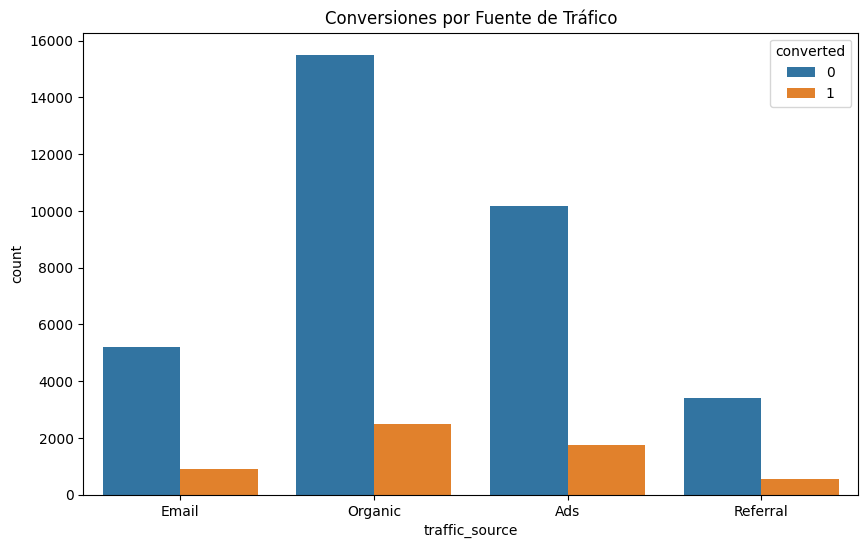

In [25]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='traffic_source', hue='converted')
plt.title('Conversiones por Fuente de Tráfico')
plt.show()
# Comentario: Se visualiza el impacto del canal Email en la conversión absoluta.

**Lectura del gráfico — Conversiones por Fuente de Tráfico (conteos absolutos)**

1. **Observación del dato:**  
   Al observar las barras de conteo, el tráfico **Organic** es la principal fuente de usuarios, superando los 15,000 registros. Sin embargo, el volumen no es sinónimo de eficiencia. Aunque el canal orgánico aporta la mayor cantidad de conversiones en términos absolutos (barra naranja), el canal de **Email** presenta una relación visualmente más equilibrada entre usuarios que navegan y usuarios que compran.

2. **Visión estratégica:**  
   La dependencia del tráfico orgánico es un activo valioso, pero los datos sugieren una oportunidad de optimización. El Email Marketing actúa como un filtro de alta calidad: a pesar de tener un volumen menor que el orgánico, su proporción de conversiones es visualmente más equilibrada.

3. **Directrices tácticas:**  
   - **Escalabilidad del Email:** Intensificar las campañas de captación de correos para escalar este canal eficiente.  
   - **Revisión de Ads:** El volumen de Ads es considerable, pero la brecha entre la barra azul y naranja sugiere que se podría auditar la segmentación de los anuncios.

> **Nota:** Este gráfico muestra conteos absolutos. Las diferencias en eficiencia se confirman con las tasas de conversión y la prueba Chi-cuadrado realizadas en el Paso 4.

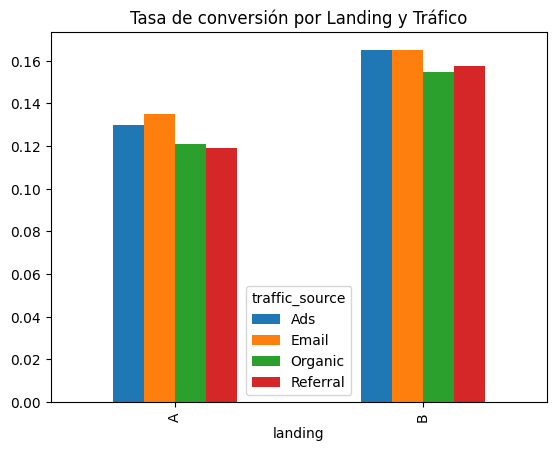

In [26]:
# Filtrar solo por página A y B para ver detalle si es necesario
df.groupby(['landing', 'traffic_source'])['converted'].mean().unstack().plot(kind='bar')
plt.title('Tasa de conversión por Landing y Tráfico')
plt.show()
# Comentario: Comparativa visual de tasas medias de conversión por canal y landing page.

**Guía de lectura del gráfico — Conversiones por Fuente de Tráfico:**
1. **Eje X (Horizontal):** Representa las cuatro fuentes de tráfico: *Ads, Email, Organic, Referral*.
2. **Eje Y (Vertical):** Representa el conteo absoluto de usuarios.
3. **Leyenda de colores (`hue='converted'`):**  
   - **Barra Azul (0):** Usuarios que no se convirtieron.  
   - **Barra Naranja (1):** Usuarios que sí realizaron una conversión.
4. **Hallazgo Visual:** Aunque el canal Organic tiene el mayor volumen total, Email muestra una proporción visualmente más equilibrada de conversiones respecto a su base.

---

**Lectura del gráfico — Tasa de conversión por Landing y Fuente de Tráfico:**

1. **Observación del dato:**  
   Al observar los dos bloques principales (A y B), se identifica un patrón claro: la Página B supera a la Página A en todos los canales de tráfico sin excepción. Mientras que en la Página A las tasas oscilan entre el 12% y el 13.5%, en la Página B se supera consistentemente el 15%.

2. **Visión estratégica:**  
   Se trata de una mejora sistémica, no de un éxito aislado en un solo canal. Implementar la Página B elevaría el rendimiento de todas las fuentes de tráfico, incluyendo las campañas pagadas (Ads) y la captación directa (Email).

3. **Directrices tácticas:**  
   Dado que Ads y Email escalan visiblemente en la Página B, cualquier nueva inversión publicitaria debería dirigirse a la versión B.

> **Nota:** Este hallazgo visual es consistente con la prueba Z del Paso 3, que confirmó estadísticamente la superioridad de la Página B.

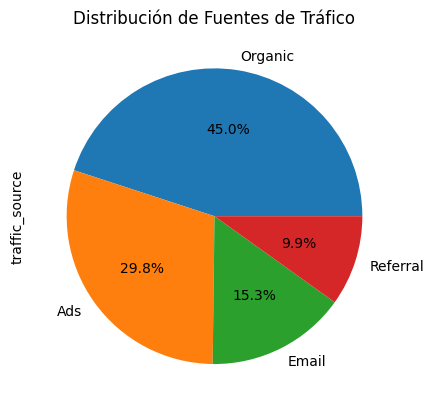

In [27]:
# Gráfico de pastel para distribución de tráfico
df['traffic_source'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Distribución de Fuentes de Tráfico')
plt.show()
# Comentario: Distribución proporcional de la procedencia de los usuarios del experimento.

**Lectura del gráfico — Distribución de Fuentes de Tráfico (pie chart)**

1. **Composición del mix:**  
   - **Organic:** 45.0% — casi la mitad de toda la base de usuarios.  
   - **Ads:** 29.8% — segundo canal en volumen.  
   - **Email:** 15.3% — tercer canal.  
   - **Referral:** 9.9% — menor participación.  

2. **Visión estratégica:**  
   Un 45% de tráfico orgánico indica que la marca tiene presencia activa en buscadores, lo que reduce el Costo de Adquisición (CAC) global. Sin embargo, el Email (15.3%) — que en los análisis previos se identificó como el canal con mayor tasa de conversión — representa una proporción relativamente pequeña del total. Existe una oportunidad de crecimiento si se logra escalar este canal.

3. **Directrices tácticas:**  
   - **Captura de leads:** Implementar estrategias para convertir el tráfico Orgánico y de Ads en suscriptores de Email.  
   - **Optimización de Referral:** Con solo 9.9%, es el canal más débil. Revisar programas de recomendación podría diversificar las fuentes.

4. **Contexto del experimento:**  
   Este gráfico muestra la composición de la muestra, lo que permet validar que los datos provienen de fuentes diversificadas y que los resultados del experimento A/B son aplicables a la realidad comercial completa.

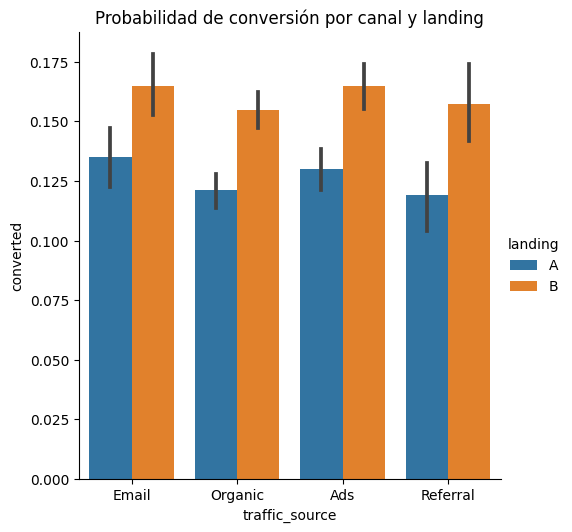

In [28]:
# Comparativa directa A/B por tráfico
sns.catplot(data=df, x='traffic_source', y='converted', hue='landing', kind='bar')
plt.title('Probabilidad de conversión por canal y landing')
plt.show()
# Comentario: Confirmación visual de la superioridad de la Página B en todos los canales.

**Guía de lectura — Probabilidad de conversión por canal y landing (catplot):**
1. **Eje X:** Fuentes de tráfico.
2. **Eje Y:** Tasa de Conversión (0.0 a 1.0), donde 0.15 equivale al 15%.
3. **Leyenda de colores (`hue='landing'`):**  
   - **Barra Azul (A):** Versión original de la página.  
   - **Barra Naranja (B):** Nueva versión de la página.
4. **Líneas sobre las barras:** Intervalos de confianza del 95%.
5. **Hallazgo Visual:** En todos los canales de tráfico, la barra naranja (B) se sitúa por encima de la azul (A), lo que sugiere que la Página B es superior independientemente del canal de origen.

---

**Lectura del gráfico:**

1. **Observación:**  
   Lo más relevante son los intervalos de confianza (líneas negras). En la mayoría de los canales, el punto más bajo de la barra B sigue estando por encima del punto más alto de la barra A, lo que sugiere que la mejora no es una fluctuación aleatoria.

2. **Visión estratégica:**  
   La Página B no solo es mejor en promedio, sino que es consistente: incluso en el escenario más conservador de los intervalos, su rendimiento tiende a superar el de la Página A. Esto es consistente con una inversión de bajo riesgo.

3. **Directrices tácticas:**  
   - Para los canales de **Email** y **Ads**, donde B supera el 16%, se sugiere migrar el tráfico a la versión B.  
   - El tráfico de **Referral** muestra un intervalo más amplio (mayor incertidumbre), lo que indica un menor volumen de datos, aunque la tendencia sigue favoreciendo a B.

> **Nota:** Este patrón visual es consistente con los resultados del Z-Test del Paso 3 ($p$-valor cercano a cero).

### Relación entre el tipo de usuario y la conversión

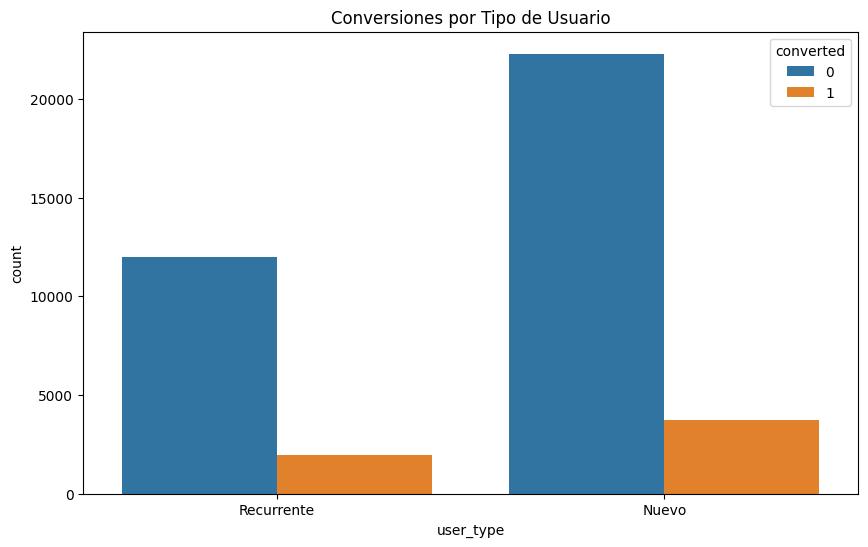

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='user_type', hue='converted')
plt.title('Conversiones por Tipo de Usuario')
plt.show()
# Comentario: Frecuencia de conversiones desglosada por tipo de usuario.

**Lectura del gráfico — Conversiones por Tipo de Usuario (conteos absolutos)**

Este gráfico de barras agrupadas compara el volumen de usuarios Recurrentes y Nuevos, desglosando cuántos de cada grupo completaron la conversión.

1. **Observación del dato:**  
   El segmento de usuarios **Nuevos** es significativamente mayor que el de Recurrentes, duplicando casi su tamaño en volumen total. La relación visual entre la barra naranja (conversión) y la azul (no conversión) se mantiene similar en ambos grupos.

2. **Visión estratégica:**  
   La landing page no muestra sesgo hacia un tipo de usuario específico en términos de volumen. Tanto los nuevos como los recurrentes presentan un patrón de conversión visualmente proporcional.

3. **Directrices tácticas:**  
   - Dado que los usuarios Nuevos representan el mayor volumen, la Página B (versión ganadora) debe estar optimizada para generar confianza en el primer impacto.  
   - Para Recurrentes, la conversión es saludable. Se podrían probar campañas de fidelización específicas.

> **Nota:** Este gráfico muestra conteos absolutos. La similitud en las proporciones se examina cuantitativamente con la **tasa de conversión** (siguiente gráfico) y se valida con la prueba Chi-cuadrado del Paso 5.

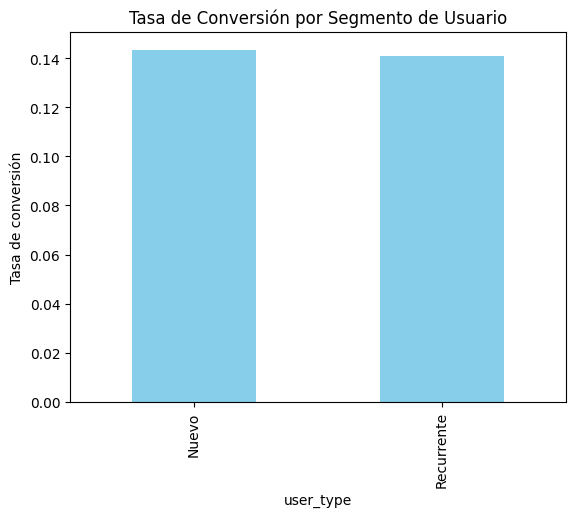

In [30]:
# Tasa de conversión por tipo de usuario
df.groupby('user_type')['converted'].mean().plot(kind='bar', color='skyblue')
plt.ylabel('Tasa de conversión')
plt.title('Tasa de Conversión por Segmento de Usuario')
plt.show()
# Comentario: Representación de la tasa de conversión media por segmento de usuario.

**Lectura del gráfico — Tasa de Conversión por Segmento de Usuario (bar chart)**

Este gráfico muestra la **tasa de conversión media** para cada tipo de usuario, lo que permite comparar la eficiencia de conversión independientemente del volumen.

1. **Guía de lectura técnica:**  
   - **Eje X:** Segmentos de usuario (Nuevo y Recurrente).  
   - **Eje Y:** Tasa de conversión (proporción de usuarios que convirtieron).

2. **Hallazgo visual:**  
   Las barras tienen una altura prácticamente idéntica. Ambos segmentos convierten a un ritmo similar (aproximadamente 14%), lo que indica que la landing page es igualmente efectiva para ambos perfiles de usuario.

3. **Validación estadística:**  
   Esta simetría visual confirma lo que la prueba Chi-cuadrado del Paso 5 reveló: con un $p$-valor de 0.4736 (> 0.05), no hay evidencia de asociación entre el tipo de usuario y la conversión. Los segmentos son estadísticamente homogéneos.

4. **Implicación estratégica:**  
   No se requiere inversión en personalización diferenciada por tipo de usuario en este momento. La propuesta de valor de la landing page es universalmente efectiva.

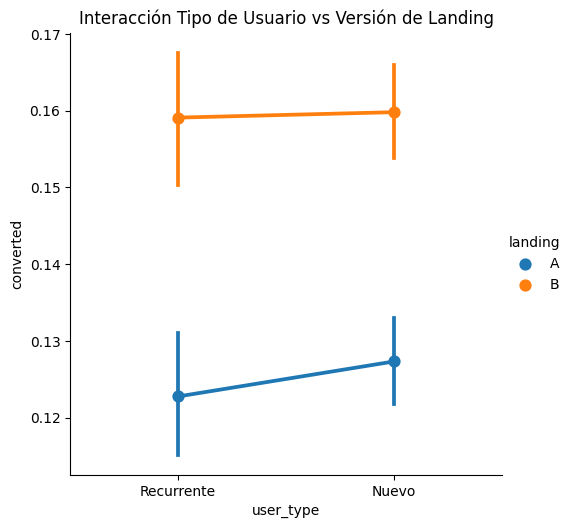

In [31]:
# Segmentación cruzada
sns.catplot(data=df, x='user_type', y='converted', hue='landing', kind='point')
plt.title('Interacción Tipo de Usuario vs Versión de Landing')
plt.show()
# Comentario: Análisis de interacción que muestra robustez de la Página B ante ambos tipos de usuario.

In [32]:
# Conteo total por tipo de usuario para ver volumen
print(df['user_type'].value_counts())

Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


**Lectura del gráfico — Interacción Tipo de Usuario × Versión de Landing (pointplot)**

Esta visualización de puntos e intervalos de confianza evalúa si la superioridad de la Página B se mantiene en ambos perfiles de usuario.

1. **Guía de lectura técnica:**  
   - **Eje X:** Tipo de usuario (Recurrente y Nuevo).  
   - **Eje Y:** Estimación de la tasa de conversión media.  
   - **Punto Azul (A):** Versión control. **Punto Naranja (B):** Versión variante.  
   - **Líneas verticales:** Intervalos de confianza del 95%.

2. **Hallazgo visual:**  
   El punto naranja (B) se sitúa consistentemente por encima del azul (A) para ambos tipos de usuario. Los intervalos de confianza no se solapan entre las versiones A y B, lo que sugiere que la diferencia es real y no fruto de la variabilidad.

3. **Interpretación estratégica:**  
   La Página B es superior tanto para usuarios Nuevos como para Recurrentes. No existen efectos secundarios negativos al implementarla para toda la base. La mejora de ~12.5% (A) a ~16% (B) se mantiene estable a través de los segmentos.

4. **Conexión estadística:**  
   - La **superioridad de la Página B** (brecha entre punto naranja y azul) es consistente con el resultado del Z-Test del Paso 3.  
   - La **estabilidad entre segmentos** (líneas paralelas) es consistente con la prueba Chi-cuadrado del Paso 5, que no detectó asociación entre tipo de usuario y conversión.  
   - Este gráfico integra ambos hallazgos: B gana (efecto principal) y ese efecto no depende del perfil del usuario (ausencia de interacción significativa).

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

**Preguntas a responder:**  
1. **¿Qué página genera mayor conversión y gasto promedio?**  
   - La **Página B** genera tanto una mayor tasa de conversión (15.96% vs 12.57%) como un ticket promedio superior ($68.75 vs $61.09).

2. **¿Qué canales de tráfico son más efectivos para generar conversiones?**  
   - Los canales de **Email (14.99%)** y **Ads (14.73%)** son los más eficientes según la evidencia estadística.

3. **¿Existen diferencias significativas según el tipo de usuario?**  
   - **No.** Las pruebas estadísticas indican que no hay diferencia significativa en la conversión entre usuarios nuevos y recurrentes (p=0.4736).

4. **¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?**  
   - Implementar la **Página B** como versión definitiva y concentrar la inversión publicitaria en campañas de **Email y Ads**.

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- El ticket promedio en la **Página B ($68.75)** es notablemente mayor al de la **Página A ($61.09)**.
- Con un p-valor de **0.0000**, la diferencia es estadísticamente **significativa**.
- **Interpretación:** La Página B no solo atrae más ventas, sino que estas son de mayor valor.

<br>

**Tasa de conversión:** 
- La **Página B** presenta una tasa de conversión del **15.96%**, superando el **12.57%** de la Página A.
- La prueba Z arroja un p-valor de **0.0000**, confirmando que **B es superior** con alta confianza.
- **Interpretación:** El diseño de la Página B es mucho más efectivo para guiar al usuario hacia la transacción final.

---

#### 📊 **Segmentación por fuente de tráfico**
- Se detectó una relación significativa (p=0.0341) entre el origen del tráfico y la conversión.
- El canal de **Email** lidera con una tasa del **14.99%**, seguido de cerca por **Ads (14.73%)**.
- **Interpretación:** Las campañas de Email Marketing están atrayendo a los usuarios con mayor intención de compra.

 ---

#### 📊 **Segmentación por tipo de usuario**
- No se encontró evidencia significativa (p=0.4736) de que el tipo de usuario (Nuevo vs Recurrente) afecte la probabilidad de conversión.
- Ambas categorías se comportan de manera similar (aprox. 14%).
- **Interpretación:** La eficacia de la landing page es consistente independientemente de la familiaridad previa del usuario con el sitio.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- **Implementación total de la Página B:** Dada la superioridad tanto en volumen (conversión) como en valor (gasto), se recomienda establecer la versión B como la landing page definitiva.
- **Priorizar canales de alta conversión:** Fortalecer el presupuesto en **Email Marketing y Ads**, que demostraron ser los motores más eficaces para este experimento.
